# 06 · Supplier side — who actually grows Indonesia's wheat, and how reliably

Notebooks 02–05 are the *domestic* production lens: Indonesia grows no wheat, and cassava→MOCAF is a
bounded domestic offset. This notebook takes the **other half of the deck's argument** — the supply-chain
fragility on slide 5 — and puts GROW production data behind it.

The deck establishes *who* Indonesia buys from (slides 3–4, trade data). It does not establish **how much
wheat those countries actually grow, or how stable that production is.** That is a QCL question, and it
turns out to be where the strongest quantified argument in the whole deck is hiding.

The question this notebook answers: **is Indonesia's import concentration risky because of who it buys
from, or because of what those crops do year to year?**

Sections:
1. Setup + who Indonesia buys from (external trade data, two bases reconciled)
2. How much wheat do the top suppliers grow? — 2010–2024 trajectory
3. Reliability — production volatility and single-year collapses
4. Australia's swing is **yield**, not area — why acreage can't hedge it
5. Are the supplier shocks correlated? → the diversification math
6. Indonesia's exposure — imports vs supplier crop size, and the tradeable pool
7. Findings

**Data provenance.** Production/area/yield: FAOSTAT QCL via `load_qcl_world`, all countries, 2010–2024.
**Import shares are NOT from this data** — FAOSTAT trade (TM) isn't downloaded in this repo, so shares are
carried in as constants from the deck and USDA GAIN, sourced inline below.

## 1. Setup + who Indonesia buys from

In [1]:
import sys; sys.path.append('..')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from src.load import load_qcl_world
from src import viz

ROOT_TABLES = Path('..') / 'outputs' / 'tables'
ROOT_TABLES.mkdir(parents=True, exist_ok=True)

WHEAT = 'Wheat'
wheat = load_qcl_world(WHEAT, ['Production', 'Area harvested', 'Yield'])
LATEST, BASE = wheat['year'].max(), wheat['year'].min()
print(f'QCL wheat: {wheat["Area"].nunique()} countries, {BASE}\u2013{LATEST}')

# Confirming the premise from nb 05, on the world frame this time.
print(f"Indonesia in the wheat producer list: {'Indonesia' in set(wheat['Area'])}")

[cache] QCL_world_wheat_2010_2024.parquet


QCL wheat: 125 countries, 2010–2024
Indonesia in the wheat producer list: False


### Supplier shares — two bases, reconciled

The deck carries two different supplier splits, and `CONTEXT.md` flags reconciling them as an open item.
They disagree because they measure different things over different windows:

| Basis | Australia | Ukraine | Canada | Window | Source |
|---|---|---|---|---|---|
| FAOSTAT import **volume** share | 25.5% | 21.3% | n/p | calendar 2024 | deck slide 4 |
| USDA GAIN import **volume** share | 37.8% | 18.3% | 16.1% | Jul'25–Jan'26 | GAIN ID2026-0010 |

Both are volume, not value — so the gap is **timing, not methodology**: the GAIN window is a marketing
year that starts after Australia's Nov–Jan harvest lands, which is exactly when Australian share peaks.
Slide 4's own series shows how violently this moves (Australia 68.6% in 2010 → 8.1% in 2020 → 25.5% in 2024).

**Recommendation for the deck:** quote the **GAIN Jul'25–Jan'26 split** for "who supplies Indonesia today"
(it's current, complete across all three, and matches the volume basis), and use slide 4's FAOSTAT series
only for the *historical instability* point. Footnote the window on both. Don't average them.

In [2]:
# Carried in from the deck / GAIN — NOT derived from QCL. See the table above.
SUPPLIER_SHARE_GAIN = {'Australia': 37.8, 'Ukraine': 18.3, 'Canada': 16.1}   # Jul'25-Jan'26, %
SUPPLIER_SHARE_FAOSTAT_2024 = {'Australia': 25.5, 'Ukraine': 21.3}           # deck slide 4, calendar 2024

TOP3 = ['Australia', 'Ukraine', 'Canada']
SECONDARY = ['Argentina', 'United States of America']   # slide 3's other named suppliers

# GAIN's three shares don't sum to 100 (other origins make up the rest); renormalise
# within the top-3 so they can be used as pool weights in section 5.
tot3 = sum(SUPPLIER_SHARE_GAIN.values())
W_ACTUAL = {k: v / tot3 for k, v in SUPPLIER_SHARE_GAIN.items()}
print(f'Top-3 = {tot3:.1f}% of Indonesia\'s wheat imports (GAIN Jul\'25-Jan\'26).')
print('Within-top-3 weights: ' + ', '.join(f'{k} {v:.0%}' for k, v in W_ACTUAL.items()))

# Indonesia's own import volume, for the exposure ratios in section 6 (GAIN, not QCL).
IDN_IMPORTS_MT = 10.45   # 2024/25 actual; 12.3 Mt forecast for 2025/26

Top-3 = 72.2% of Indonesia's wheat imports (GAIN Jul'25-Jan'26).
Within-top-3 weights: Australia 52%, Ukraine 25%, Canada 22%


## 2. How much wheat do the top suppliers actually grow?

First the level: are these big producers, or small ones that happen to export a lot?

In [3]:
prod = wheat[wheat['Element'] == 'Production'].pivot_table(
    index='year', columns='Area', values='value') / 1e6      # tonnes -> Mt

world_latest = prod.loc[LATEST].sum()
tbl = pd.DataFrame({
    f'production_Mt_{LATEST}': prod.loc[LATEST],
    f'%_of_world_{LATEST}': 100 * prod.loc[LATEST] / world_latest,
    f'mean_Mt_{BASE}_{LATEST}': prod.mean(),
})
print(f'World wheat production {LATEST}: {world_latest:,.0f} Mt\n')
print('Indonesia\'s named suppliers:')
print(tbl.loc[TOP3 + SECONDARY].round(1).to_string())
print('\nFor scale \u2014 the biggest producers overall:')
print(tbl.sort_values(f'production_Mt_{LATEST}', ascending=False).head(6).round(1).to_string())

World wheat production 2024: 798 Mt

Indonesia's named suppliers:
                          production_Mt_2024  %_of_world_2024  mean_Mt_2010_2024
Area                                                                            
Australia                               34.1              4.3               27.2
Ukraine                                 22.4              2.8               23.7
Canada                                  35.9              4.5               30.7
Argentina                               18.5              2.3               15.7
United States of America                53.7              6.7               53.5

For scale — the biggest producers overall:
                          production_Mt_2024  %_of_world_2024  mean_Mt_2010_2024
Area                                                                            
China, mainland                        140.1             17.5              130.2
India                                  113.3             14.2               98.8

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_supply_supplier_production.png


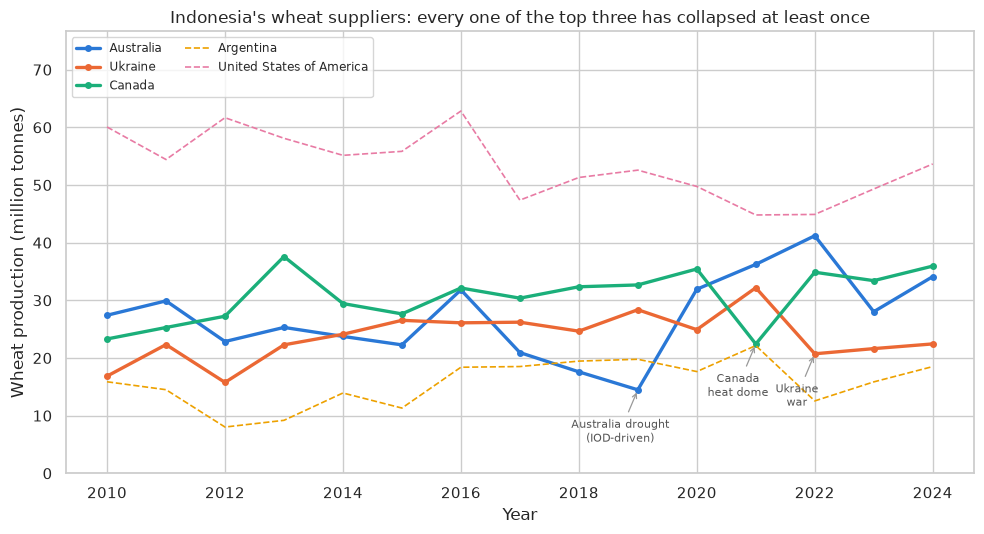

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for c, color in zip(TOP3 + SECONDARY, viz.CATEGORICAL_COLORS):
    lw = 2.4 if c in TOP3 else 1.2
    ls = '-' if c in TOP3 else '--'
    ax.plot(prod.index, prod[c], label=c, color=color, lw=lw, ls=ls,
            marker='o' if c in TOP3 else None, ms=4)

# Shock annotations. Cause attribution is EXTERNAL (deck slide 5 + its sources);
# only the production drop itself comes from QCL.
for yr, txt, c in [(2019, 'Australia drought\n(IOD-driven)', 'Australia'),
                   (2021, 'Canada\nheat dome', 'Canada'),
                   (2022, 'Ukraine\nwar', 'Ukraine')]:
    ax.annotate(txt, xy=(yr, prod[c].loc[yr]), xytext=(yr - 0.3, prod[c].loc[yr] - 9),
                fontsize=8, ha='center', color='#555',
                arrowprops=dict(arrowstyle='->', color='#999', lw=0.9))

ax.set_ylim(0, prod[TOP3 + SECONDARY].max().max() * 1.22)   # headroom so the legend clears the US line
ax.set_ylabel('Wheat production (million tonnes)')
ax.set_xlabel('Year')
ax.set_title("Indonesia's wheat suppliers: every one of the top three has collapsed at least once")
ax.legend(fontsize=8.5, loc='upper left', ncol=2)
fig.tight_layout()
viz.save(fig, 'idn_supply_supplier_production')
plt.show()

## 3. Reliability — how volatile is each supplier's crop?

Level isn't the risk; **variance** is. Two measures: the coefficient of variation (CV = std ÷ mean, so it's
comparable across countries of different size) and the worst single-year drop in the window.

In [5]:
def reliability(cols):
    rows = []
    for c in cols:
        s = prod[c]
        yoy = s.pct_change() * 100
        rows.append({'supplier': c,
                     'mean_Mt': s.mean(),
                     'CV_%': 100 * s.std() / s.mean(),
                     'worst_1yr_drop_%': yoy.min(),
                     'worst_year': int(yoy.idxmin()),
                     'max_over_min': s.max() / s.min()})
    return pd.DataFrame(rows).set_index('supplier').sort_values('CV_%', ascending=False)

rel = reliability(TOP3 + SECONDARY + ['Russian Federation', 'France', 'China, mainland', 'India'])
print(rel.round(1).to_string())
print()
worst = rel.loc[TOP3, 'worst_1yr_drop_%']
print(f'All three of Indonesia\'s main suppliers lost \u2265{abs(worst.max()):.0f}% of their wheat crop '
      f'in a single year at some point in {BASE}\u2013{LATEST}:')
for c in TOP3:
    print(f'  {c:12s} {rel.loc[c, "worst_1yr_drop_%"]:6.1f}% in {rel.loc[c, "worst_year"]}')
print(f'\nAustralia \u2014 Indonesia\'s LARGEST supplier ({SUPPLIER_SHARE_GAIN["Australia"]}%) \u2014 is also the '
      f'most volatile\nmajor producer in the table (CV {rel.loc["Australia", "CV_%"]:.1f}%), swinging '
      f'{prod["Australia"].min():.1f}\u2013{prod["Australia"].max():.1f} Mt ({rel.loc["Australia", "max_over_min"]:.1f}x).')
print(f'Contrast the non-exporters: China {rel.loc["China, mainland", "CV_%"]:.1f}%, '
      f'India {rel.loc["India", "CV_%"]:.1f}% \u2014 stable, and unavailable.')

                          mean_Mt  CV_%  worst_1yr_drop_%  worst_year  max_over_min
supplier                                                                           
Russian Federation           70.4  26.7             -32.9        2012           2.8
Australia                    27.2  26.5             -34.2        2017           2.8
Argentina                    15.7  26.0             -44.7        2012           2.8
Ukraine                      23.7  17.7             -35.6        2022           2.0
Canada                       30.7  15.2             -36.7        2021           1.7
France                       36.0  12.1             -31.4        2016           1.6
United States of America     53.5  10.6             -24.6        2017           1.4
India                        98.8  10.0              -9.7        2015           1.4
China, mainland             130.2   6.0              -2.1        2018           1.2

All three of Indonesia's main suppliers lost ≥34% of their wheat crop in a 

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_supplier_reliability.png


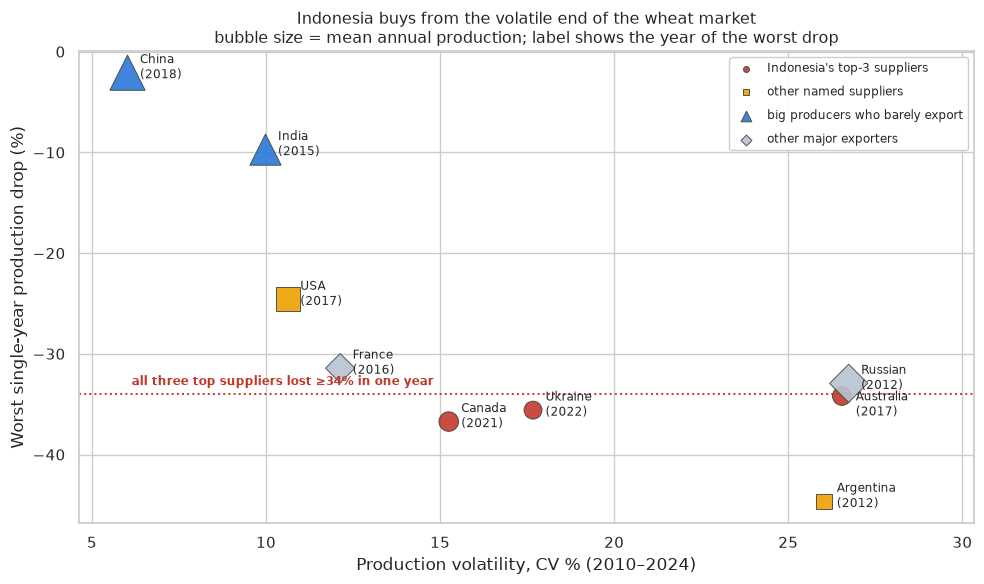

In [6]:
# Plot for the reliability table above. Volatility vs worst single year, so the two things that
# matter about a supplier sit on one pair of axes: how variable, and how bad has it actually got.
fig, ax = plt.subplots(figsize=(10, 6))
GROUPS = {
    "Indonesia's top-3 suppliers": (TOP3, '#c0392b', 'o'),
    'other named suppliers':       (SECONDARY, '#eda100', 's'),
    'big producers who barely export': (['China, mainland', 'India'], '#2a78d6', '^'),
    'other major exporters':       (['Russian Federation', 'France'], '#b8c4d1', 'D'),
}
for label, (members, colour, marker) in GROUPS.items():
    sub = rel.loc[[m for m in members if m in rel.index]]
    ax.scatter(sub['CV_%'], sub['worst_1yr_drop_%'], s=sub['mean_Mt'] * 4.5 + 60,
               c=colour, marker=marker, edgecolors='#444', linewidths=0.7,
               label=label, zorder=3, alpha=0.9)
    for name, r in sub.iterrows():
        short = name.replace(', mainland', '').replace(' Federation', '')
        short = {'United States of America': 'USA'}.get(short, short)
        # Australia (26.5, -34.2) and Russia (26.7, -32.9) nearly coincide — split them by hand
        off = {'Australia': (10, -14), 'Russia': (10, 6)}.get(short, (9, -4))
        ax.annotate(f"{short}\n({int(r['worst_year'])})", (r['CV_%'], r['worst_1yr_drop_%']),
                    xytext=off, textcoords='offset points', fontsize=8.3, zorder=4)

ax.axhline(-34, color='#c0392b', ls=':', lw=1.4, zorder=1)
# left side is empty at this depth; the right side is where Australia/Russia sit
ax.text(rel['CV_%'].min() * 1.02, -33.4, 'all three top suppliers lost \u226534% in one year',
        color='#c0392b', fontsize=8.6, fontweight='bold', ha='left', va='bottom')
ax.set_xlim(rel['CV_%'].min() - 1.4, rel['CV_%'].max() + 3.6)   # room for the right-edge labels
ax.set_xlabel('Production volatility, CV % (2010\u20132024)')
ax.set_ylabel('Worst single-year production drop (%)')
ax.set_title('Indonesia buys from the volatile end of the wheat market\n'
             'bubble size = mean annual production; label shows the year of the worst drop',
             fontsize=11.5)
# markerscale: legend inherits the bubble sizing otherwise and the box becomes unreadable
ax.legend(fontsize=8.5, loc='upper right', framealpha=0.95, markerscale=0.32, labelspacing=0.9)
fig.tight_layout()
viz.save(fig, 'idn_supplier_reliability')
plt.show()

## 4. Australia's swing is **yield**, not area

This matters for whether the risk is manageable. If a supplier's production wobbles because farmers plant
more or less, that responds to price and policy. If it wobbles because of **yield**, it's weather — and no
contract, subsidy or acreage program hedges it.

In [7]:
aus = wheat[wheat['Area'] == 'Australia'].pivot_table(
    index='year', columns='Element', values='value')
a_cv = 100 * aus['Area harvested'].std() / aus['Area harvested'].mean()
y_cv = 100 * aus['Yield'].std() / aus['Yield'].mean()
print(f'Australia, {BASE}\u2013{LATEST}:  area CV {a_cv:.1f}%   vs   yield CV {y_cv:.1f}%'
      f'   ({y_cv/a_cv:.1f}x more variable)\n')

trough, peak = int(aus['Yield'].idxmin()), int(aus['Yield'].idxmax())
print(f'Yield trough {trough}: {aus["Yield"].loc[trough]:,.0f} kg/ha   '
      f'peak {peak}: {aus["Yield"].loc[peak]:,.0f} kg/ha   '
      f'({aus["Yield"].loc[peak]/aus["Yield"].loc[trough]:.1f}x)')
print(f'Area over the same two years: {aus["Area harvested"].loc[trough]/1e6:.1f}M ha -> '
      f'{aus["Area harvested"].loc[peak]/1e6:.1f}M ha (barely moved by comparison)')
print(f'\ncorr(area, production)  = {aus["Area harvested"].corr(aus["Production"]):+.2f}')
print(f'corr(yield, production) = {aus["Yield"].corr(aus["Production"]):+.2f}   <- production IS yield')
print('\n-> Australia grows a fairly constant footprint of wheat and harvests wildly different amounts')
print('   from it. That is climate risk, and it is why the deck\'s El Nino / IOD angle belongs on the')
print('   supply side, not just as background colour.')

Australia, 2010–2024:  area CV 10.1%   vs   yield CV 21.9%   (2.2x more variable)

Yield trough 2019: 1,468 kg/ha   peak 2022: 3,188 kg/ha   (2.2x)
Area over the same two years: 9.9M ha -> 12.9M ha (barely moved by comparison)

corr(area, production)  = +0.65
corr(yield, production) = +0.95   <- production IS yield

-> Australia grows a fairly constant footprint of wheat and harvests wildly different amounts
   from it. That is climate risk, and it is why the deck's El Nino / IOD angle belongs on the
   supply side, not just as background colour.


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_supply_australia_area_vs_yield.png


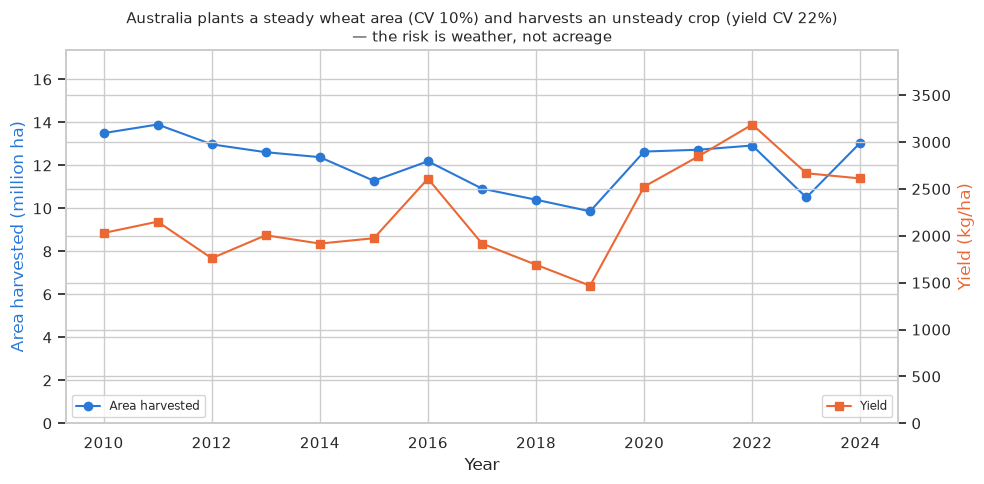

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()
ax.plot(aus.index, aus['Area harvested'] / 1e6, color='#2a78d6', marker='o', label='Area harvested')
ax2.plot(aus.index, aus['Yield'], color='#eb6834', marker='s', label='Yield')
ax.set_ylabel('Area harvested (million ha)', color='#2a78d6')
ax2.set_ylabel('Yield (kg/ha)', color='#eb6834')
ax.set_ylim(0, aus['Area harvested'].max() / 1e6 * 1.25)
ax2.set_ylim(0, aus['Yield'].max() * 1.25)
ax.set_xlabel('Year')
ax.set_title(f'Australia plants a steady wheat area (CV {a_cv:.0f}%) and harvests an unsteady crop '
             f'(yield CV {y_cv:.0f}%)\n\u2014 the risk is weather, not acreage', fontsize=11)
ax.legend(loc='lower left', fontsize=8.5)
ax2.legend(loc='lower right', fontsize=8.5)
fig.tight_layout()
viz.save(fig, 'idn_supply_australia_area_vs_yield')
plt.show()

## 5. Are the shocks correlated? — the diversification math

Diversifying suppliers only helps if their bad years **don't coincide**. This is testable, and it converts
the deck's "diversify" recommendation from a platitude into a number.

In [9]:
yoy = prod[TOP3].pct_change().dropna() * 100
print('Correlation of year-on-year production change:')
print(yoy.corr().round(2).to_string())
print('\nYear-by-year % change \u2014 note the bad years land in DIFFERENT years:')
print(yoy.round(0).to_string())
print('\n2017 Australia -34% while Ukraine held flat and Canada -5%.')
print('2021 Canada -37% while Australia +14% and Ukraine +29%.')
print('2022 Ukraine -36% (war) while Canada +56% and Australia +14%.')
print('\n-> Near-zero to negative correlations: these are independent climate/geopolitical systems.')
print('   Pooling them genuinely reduces risk, which is not true of correlated suppliers.')

Correlation of year-on-year production change:
Area       Australia  Ukraine  Canada
Area                                 
Australia       1.00    -0.09    0.20
Ukraine        -0.09     1.00   -0.34
Canada          0.20    -0.34    1.00

Year-by-year % change — note the bad years land in DIFFERENT years:
Area  Australia  Ukraine  Canada
year                            
2011        9.0     32.0     9.0
2012      -24.0    -29.0     8.0
2013       11.0     41.0    38.0
2014       -6.0      8.0   -22.0
2015       -6.0     10.0    -6.0
2016       43.0     -2.0    16.0
2017      -34.0      0.0    -5.0
2018      -16.0     -6.0     7.0
2019      -18.0     15.0     1.0
2020      120.0    -12.0     8.0
2021       14.0     29.0   -37.0
2022       14.0    -36.0    56.0
2023      -32.0      4.0    -4.0
2024       22.0      4.0     8.0

2017 Australia -34% while Ukraine held flat and Canada -5%.
2021 Canada -37% while Australia +14% and Ukraine +29%.
2022 Ukraine -36% (war) while Canada +56% and Aus

In [10]:
# What each sourcing mix would have felt like, applied to actual 2010-2024 production.
SCENARIOS = {
    'Australia only (max concentration)':        {'Australia': 1.0},
    "Actual mix, GAIN Jul'25\u2013Jan'26":            W_ACTUAL,
    'Equal-weight across the top 3':             {c: 1 / 3 for c in TOP3},
}
rows = []
for name, wts in SCENARIOS.items():
    pool = sum(prod[k] * v for k, v in wts.items())
    rows.append({'sourcing mix': name,
                 'pool_CV_%': 100 * pool.std() / pool.mean(),
                 'worst_1yr_drop_%': 100 * pool.pct_change().min()})
div = pd.DataFrame(rows).set_index('sourcing mix')
print(div.round(1).to_string())

base_cv = div.loc['Australia only (max concentration)', 'pool_CV_%']
act_cv  = div.loc["Actual mix, GAIN Jul'25\u2013Jan'26", 'pool_CV_%']
eq_cv   = div.loc['Equal-weight across the top 3', 'pool_CV_%']
print(f'\nConcentrating on Australia alone: CV {base_cv:.1f}%.')
print(f"Indonesia's actual mix already cuts that to {act_cv:.1f}% \u2014 diversification is working.")
print(f'But rebalancing from Australia-heavy to an even split would cut it further to {eq_cv:.1f}%,')
print(f'a {100*(act_cv-eq_cv)/act_cv:.0f}% relative reduction in supply volatility \u2014 and it improves the')
act_worst = div.loc["Actual mix, GAIN Jul'25\u2013Jan'26", 'worst_1yr_drop_%']
eq_worst  = div.loc['Equal-weight across the top 3', 'worst_1yr_drop_%']
print(f'worst single year, from {act_worst:.0f}% to {eq_worst:.0f}%.')
print('\nCaveat: this is a production-side risk metric only. It ignores freight cost, wheat')
print('protein/quality class (Australian ASW vs Canadian CWRS are not interchangeable for all')
print('millers), and contract availability \u2014 all of which constrain how far Indonesia can rebalance.')

out = ROOT_TABLES / 'supplier_diversification_scenarios.csv'
div.to_csv(out)
print(f'\ntable -> {out}')

                                    pool_CV_%  worst_1yr_drop_%
sourcing mix                                                   
Australia only (max concentration)       26.5             -34.2
Actual mix, GAIN Jul'25–Jan'26           14.9             -20.2
Equal-weight across the top 3            11.6             -15.0

Concentrating on Australia alone: CV 26.5%.
Indonesia's actual mix already cuts that to 14.9% — diversification is working.
But rebalancing from Australia-heavy to an even split would cut it further to 11.6%,
a 22% relative reduction in supply volatility — and it improves the
worst single year, from -20% to -15%.

Caveat: this is a production-side risk metric only. It ignores freight cost, wheat
protein/quality class (Australian ASW vs Canadian CWRS are not interchangeable for all
millers), and contract availability — all of which constrain how far Indonesia can rebalance.

table -> ../outputs/tables/supplier_diversification_scenarios.csv


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_supply_diversification.png


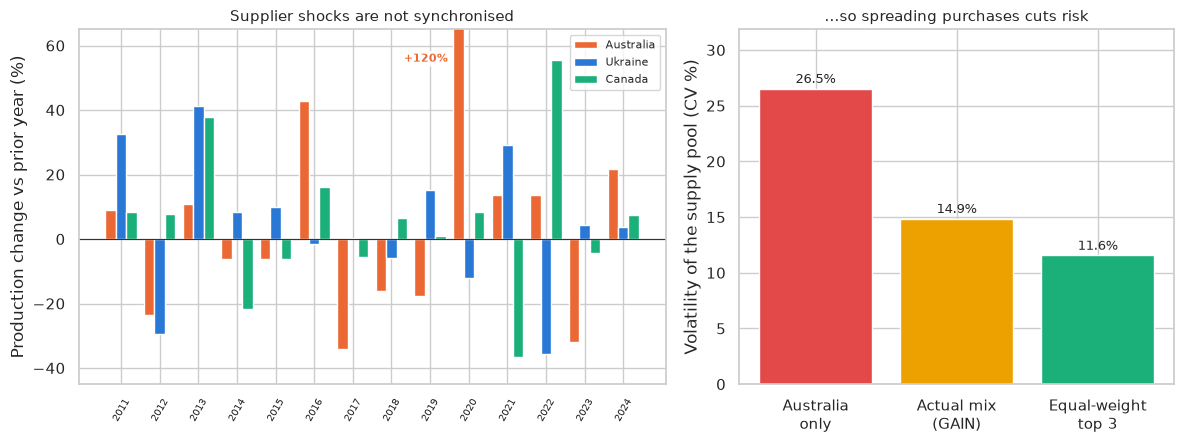

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={'width_ratios': [1.35, 1]})

# Left: shocks land in different years.
ax = axes[0]
x = np.arange(len(yoy))
w = 0.27
for k, (c, color) in enumerate(zip(TOP3, ['#eb6834', '#2a78d6', '#1baf7a'])):
    ax.bar(x + (k - 1) * w, yoy[c], width=w, color=color, label=c)
ax.axhline(0, color='#333', lw=0.8)
# Australia's 2020 rebound (+120%) is real but 3x the next-largest move; clipping the axis
# keeps the DOWNSIDE shocks — the thing at issue — legible. Clipped bar labelled instead.
ax.set_ylim(-45, 65)
big = list(yoy.index).index(yoy['Australia'].idxmax())
ax.annotate(f"+{yoy['Australia'].max():.0f}%", xy=(big - 2.0 * w, 55), ha='right',
            fontsize=8, color='#eb6834', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85))
ax.set_xticks(x, [str(y) for y in yoy.index], rotation=60, fontsize=7.5)
ax.set_ylabel('Production change vs prior year (%)')
ax.set_title('Supplier shocks are not synchronised', fontsize=10.5)
ax.legend(fontsize=8)

# Right: what that buys you.
ax = axes[1]
lbl = ['Australia\nonly', "Actual mix\n(GAIN)", 'Equal-weight\ntop 3']
vals = div['pool_CV_%'].values
bars = ax.bar(lbl, vals, color=['#e34948', '#eda100', '#1baf7a'])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9.5)
ax.set_ylim(0, max(vals) * 1.2)
ax.set_ylabel('Volatility of the supply pool (CV %)')
ax.set_title('...so spreading purchases cuts risk', fontsize=10.5)

fig.tight_layout()
viz.save(fig, 'idn_supply_diversification')
plt.show()

## 6. Indonesia's exposure — and how small the tradeable pool really is

Two framings the deck doesn't currently have. First: Indonesia isn't a marginal buyer of these crops.
Second: "the world grows plenty of wheat" is misleading, because most of it never reaches a world market.

In [12]:
print(f"Indonesia's {IDN_IMPORTS_MT} Mt of wheat imports, as a share of each supplier's "
      f"{LATEST} crop:\n")
for c in TOP3 + SECONDARY:
    print(f'  {c:26s} {100*IDN_IMPORTS_MT/prod[c].loc[LATEST]:5.1f}%   '
          f'(crop {prod[c].loc[LATEST]:5.1f} Mt)')
print('\n-> Indonesia alone needs the equivalent of roughly a THIRD of Australia\'s entire wheat')
print('   harvest. This is a mutual dependency, which is leverage \u2014 but it also means there is no')
print('   spare capacity to absorb a bad year quietly.')

NON_EXPORTERS = ['China, mainland', 'India', 'Pakistan']
MAJOR_EXPORTERS = ['Russian Federation', 'United States of America', 'Canada',
                   'Australia', 'Ukraine', 'Argentina', 'France']
ne = prod.loc[LATEST, NON_EXPORTERS].sum()
me = prod.loc[LATEST, MAJOR_EXPORTERS].sum()
print(f'\nWorld wheat production, {LATEST}: {world_latest:,.0f} Mt')
print(f'  China + India + Pakistan (produce huge volumes, export almost none): '
      f'{ne:,.0f} Mt = {100*ne/world_latest:.0f}%')
print(f'  The 7 major exporters:                                             '
      f'{me:,.0f} Mt = {100*me/world_latest:.0f}%')
print(f'  Indonesia\'s imports as a share of those 7 exporters\' output:       '
      f'{100*IDN_IMPORTS_MT/me:.1f}%')
print(f'  ...and of the top-3 suppliers\' output alone:                       '
      f'{100*IDN_IMPORTS_MT/prod.loc[LATEST, TOP3].sum():.1f}%')
print('\n-> The relevant denominator is not world production, it is the ~1/3 of it that is actually')
print('   traded. Indonesia is competing for a slice of a pool that is both smaller and more')
print('   volatile than the headline world figure suggests.')

Indonesia's 10.45 Mt of wheat imports, as a share of each supplier's 2024 crop:

  Australia                   30.6%   (crop  34.1 Mt)
  Ukraine                     46.6%   (crop  22.4 Mt)
  Canada                      29.1%   (crop  35.9 Mt)
  Argentina                   56.5%   (crop  18.5 Mt)
  United States of America    19.5%   (crop  53.7 Mt)

-> Indonesia alone needs the equivalent of roughly a THIRD of Australia's entire wheat
   harvest. This is a mutual dependency, which is leverage — but it also means there is no
   spare capacity to absorb a bad year quietly.

World wheat production, 2024: 798 Mt
  China + India + Pakistan (produce huge volumes, export almost none): 285 Mt = 36%
  The 7 major exporters:                                             274 Mt = 34%
  Indonesia's imports as a share of those 7 exporters' output:       3.8%
  ...and of the top-3 suppliers' output alone:                       11.3%

-> The relevant denominator is not world production, it is the ~1/3 

## 7. Findings — supplier-side case for the deck

**Who Indonesia buys from (external trade data):** Australia **37.8%**, Ukraine **18.3%**, Canada **16.1%**
(GAIN, Jul'25–Jan'26) — 72% of imports from three countries. Use this basis, not slide 4's calendar-2024
FAOSTAT split; the two differ by *window*, not method (see §1).

**What GROW production data adds:**

1. **These are mid-sized producers, not giants.** Australia 34.1 Mt, Canada 35.9 Mt, Ukraine 22.4 Mt in 2024
   — together **11.6% of world wheat**. Indonesia's supply security rests on a narrow slice of global output.
2. **Every one of the top three has lost ≥34% of its crop in a single year since 2010** — Australia −34%
   (2017), Canada −37% (2021), Ukraine −36% (2022). This is not a tail risk; it happened three times in
   fifteen years, once per supplier.
3. **Indonesia's largest supplier is also the least reliable.** Australia has the highest volatility of any
   major producer examined (CV **26.5%**), swinging **14.5 → 41.2 Mt** (2.8×) across the window.
4. **Australia's swing is yield, not area** (yield CV **21.9%** vs area CV **10.1%** — 2.2x more variable;
   `corr(yield, production) = +0.95` vs `corr(area, production) = +0.65`).
   Australia plants a steady footprint and harvests wildly different amounts from it — so this is weather
   risk that **no contract or acreage policy can hedge**. This is where the deck's El Niño/IOD angle
   actually belongs: on the supply side, quantified.
5. **The shocks are uncorrelated** (Australia–Ukraine −0.09, Ukraine–Canada −0.34, Australia–Canada +0.20),
   and land in different years. So diversification is genuinely protective rather than cosmetic:
   Australia-only sourcing carries CV **26.5%**; Indonesia's actual mix already cuts that to **14.9%**;
   an **equal split across the three would reach 11.6%** — a further **22% relative** cut, and it improves
   the worst single year from −20% to −15%.
6. **Indonesia is not a marginal buyer.** Its 10.45 Mt is **31% of Australia's**, **47% of Ukraine's** and
   **29% of Canada's** entire 2024 crop. That is mutual dependency (leverage in negotiation) but also means
   no supplier has quiet spare capacity in a bad year.
7. **The tradeable pool is ~1/3 of world production.** China, India and Pakistan grow **36%** of world wheat
   and export almost none; the seven major exporters account for **34%**. "The world grows plenty of wheat"
   is not a comfort available to Indonesia.

**How this pairs with the MOCAF argument (nb 05):**
> The two levers are complementary, and now both are sized. **Supplier rebalancing** is cheap, fast, and
> worth a **~22% cut in supply volatility** — but it cannot reduce the 12.3 Mt Indonesia has to buy.
> **Cassava→MOCAF** reduces the volume itself, but is bounded at an **8–14% blend** on land-neutral terms
> (nb 05 §6). Neither is sufficient alone; the deck should present them as a two-track recommendation with
> the volatility number attached to track one and the blend band attached to track two.

**Caveats.** Import shares are external inputs, not derived here — FAOSTAT trade (TM) is not downloaded in
this repo, and adding it would let this analysis compute shares directly and check the deck's two bases
against each other properly. The diversification metric is production-side only: it ignores freight,
wheat protein/quality class (Australian ASW and Canadian CWRS are not interchangeable for every miller),
and contract availability. Shock *causes* (drought, IOD, war, heat dome) are attributed from the deck's
external sources — QCL shows only the drop.

In [13]:
print('Notebook 06 complete.')
print('  figures -> outputs/figures/idn_supply_supplier_production.png,')
print('             idn_supply_australia_area_vs_yield.png, idn_supply_diversification.png')
print(f'  table   -> {ROOT_TABLES / "supplier_diversification_scenarios.csv"}')

Notebook 06 complete.
  figures -> outputs/figures/idn_supply_supplier_production.png,
             idn_supply_australia_area_vs_yield.png, idn_supply_diversification.png
  table   -> ../outputs/tables/supplier_diversification_scenarios.csv
